In [16]:
from google.colab import drive
drive.mount('/content/drive')


img_path = "/content/drive/MyDrive/PA_datos/TPF/Test/TP_final_10casos/dicom_to_png/10033.dcm"
dcm_path = "/content/drive/MyDrive/PA_datos/TPF/Test/TP_final_10casos/dicom_to_png/10033.dcm"
png_path = "/content/drive/MyDrive/PA_datos/TPF/Test/TP_final_10casos/dicom_to_png/10033.png"

Mounted at /content/drive


In [ ]:
pip install pydicom

In [ ]:
import os
import numpy as np
import pydicom
import imageio.v2 as imageio
import matplotlib.pyplot as plt

def dicom_to_array(ds: pydicom.Dataset) -> np.ndarray:
    """Devuelve pixel array como float32, aplicando slope/intercept si existen."""
    arr = ds.pixel_array.astype(np.float32)

    slope = float(getattr(ds, "RescaleSlope", 1.0))
    intercept = float(getattr(ds, "RescaleIntercept", 0.0))
    arr = arr * slope + intercept
    return arr

def apply_window(img_hu: np.ndarray, wc: float, ww: float) -> np.ndarray:
    """Aplica windowing y devuelve float32 en [0,1]."""
    lo = wc - ww / 2.0
    hi = wc + ww / 2.0
    x = np.clip(img_hu, lo, hi)
    x = (x - lo) / (hi - lo + 1e-9)
    return x.astype(np.float32)

def save_png_from_dicom(dcm_path: str, png_path: str, wc=40, ww=120):
    ds = pydicom.dcmread(dcm_path)
    img_hu = dicom_to_array(ds)

    img01 = apply_window(img_hu, wc, ww)
    img_u8 = (img01 * 255.0).round().astype(np.uint8)

    os.makedirs(os.path.dirname(png_path) or ".", exist_ok=True)
    imageio.imwrite(png_path, img_u8)

    return img_hu, img01, (wc, ww)

def ensure_png(path: str, wc=40, ww=120):
  ext = os.path.splitext(path)[1].lower()
  if ext == ".dcm":
    ds = pydicom.dcmread(path)
    img_hu = dicom_to_array(ds)

    img01 = apply_window(img_hu, wc, ww)
    img_u8 = (img01 * 255.0).round().astype(np.uint8)

    if img_u8.ndim == 3:
        img_u8 = img_u8[..., 0]
    return (img_u8.astype(np.float32) / 255.0)

  elif ext == ".png":
    im = imageio.imread(path)
    if im.ndim == 3:
      im = (0.2126*im[...,0] + 0.7152*im[...,1] + 0.0722*im[...,2]).astype(np.uint8)

    png_u8 = im.astype(np.uint8)
    img01 = (png_u8.astype(np.float32) / 255.0)
    return img01

  else:
    raise ValueError("Formato no soportado. Solo .dcm o .png")


def load_png_as_float01(png_path: str) -> np.ndarray:
    im = imageio.imread(png_path)
    if im.ndim == 3:
        im = im[..., 0]
    return (im.astype(np.float32) / 255.0)

def compare_images(img01_from_dicom: np.ndarray, img01_from_png: np.ndarray, title="Comparación"):
    # Alinear shapes por si acaso
    if img01_from_dicom.shape != img01_from_png.shape:
        raise ValueError(f"Shapes distintas: dicom {img01_from_dicom.shape} vs png {img01_from_png.shape}")

    diff = np.abs(img01_from_dicom - img01_from_png)
    print("Diff stats -> mean:", float(diff.mean()), "max:", float(diff.max()))

    plt.figure(figsize=(12,4))
    plt.subplot(1,3,1); plt.imshow(img01_from_dicom, cmap="gray"); plt.title("DICOM (windowed)"); plt.axis("off")
    plt.subplot(1,3,2); plt.imshow(img01_from_png,  cmap="gray"); plt.title("PNG cargada"); plt.axis("off")
    plt.subplot(1,3,3); plt.imshow(diff, cmap="gray"); plt.title("Abs diff"); plt.axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

# =========================
# USO
# =========================

# Si querés forzar ventana:
#wc, ww = 40, 80  # CT head típico
#img_hu, img01, (wc_used, ww_used) = save_png_from_dicom(dcm_path, png_path, wc=wc, ww=ww)

#img_hu, img01, (wc_used, ww_used) = save_png_from_dicom(img_path, png_path)
#print("Guardado PNG en:", img_path)

img_png = ensure_png(img_path)

#img01_png = load_png_as_float01(png_path)
#compare_images(img_png, img01, title="DICOM → PNG → load")

In [ ]:
img_png
#img01_png_2

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

In [ ]:
png_path_2 = '/content/drive/MyDrive/PA_datos/TPF/Test/TP_final_10casos/10033.png'
img01_png_2 = load_png_as_float01(png_path_2)
print("Cargado PNG en:", png_path_2)

Cargado PNG en: /content/drive/MyDrive/PA_datos/TPF/Test/TP_final_10casos/10033.png


Diff stats -> mean: 0.0008678061421960592 max: 0.011764705181121826


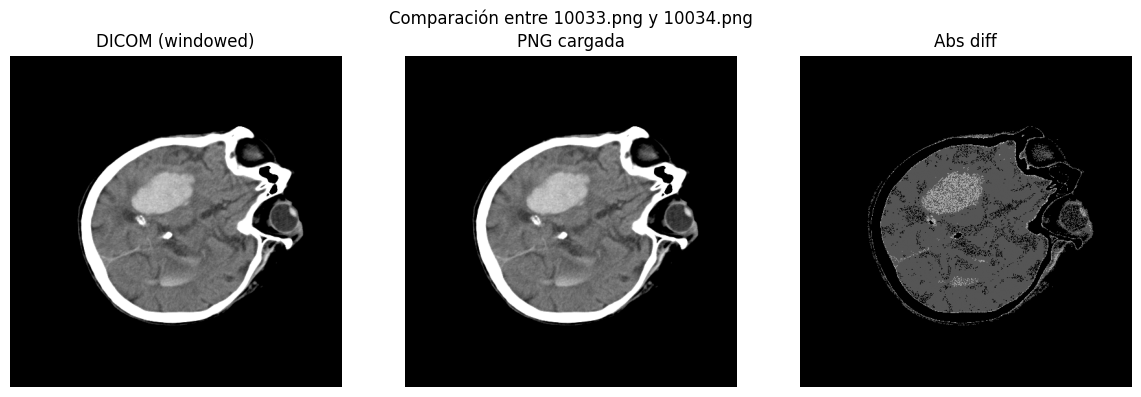

In [ ]:
compare_images(img_png, img01_png_2, title="Comparación entre 10033.png y 10034.png")

## Load Model





In [ ]:
import torch

model_path = '/content/drive/MyDrive/_tp_models/best_all_model.pth'
model = torch.load(model_path)

In [ ]:
import numpy as np

# Convert numpy array to torch tensor
img_tensor = torch.from_numpy(img_png).float()

# Add channel dimension (grayscale images have 1 channel) and batch dimension
# Expected shape for a PyTorch model is usually (batch_size, channels, height, width)
img_tensor = img_tensor.unsqueeze(0).unsqueeze(0)

print(f"Shape of img_tensor after preprocessing: {img_tensor.shape}")

Shape of img_tensor after preprocessing: torch.Size([1, 1, 512, 512])


In [ ]:
import torch.nn as nn
import torch.nn.functional as F

# Define ImageClassificationBase as an nn.Module
class ImageClassificationBase(nn.Module):
    def __init__(self):
        super().__init__()

# Define ConvBlock as it's used in residual blocks
# This version directly contains Conv2d, BatchNorm2d, ReLU as specified for residual blocks
class ConvBlock(nn.Sequential):
    def __init__(self, in_channels, out_channels):
        super().__init__(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

# Redefine the CNN_NeuralNet model to match the state_dict
class CNN_NeuralNet(ImageClassificationBase):
    def __init__(self, in_channels, num_diseases):
        super().__init__()

        # conv1 uses the ConvBlock structure
        self.conv1 = ConvBlock(in_channels, 64)

        # conv2, conv3, conv4 are Sequential blocks containing Conv2d, BatchNorm2d, ReLU, MaxPool2d directly
        self.conv2 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2)
        )
        # Residual block 1
        self.res1 = nn.Sequential(ConvBlock(128, 128), ConvBlock(128, 128))

        self.conv3 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2)
        )
        # Residual block 2
        self.res2 = nn.Sequential(ConvBlock(256, 256), ConvBlock(256, 256))

        self.conv4 = nn.Sequential(
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2)
        )
        # Residual block 3
        self.res3 = nn.Sequential(ConvBlock(512, 512), ConvBlock(512, 512))

        # Classifier head
        self.classifier = nn.Sequential(
                nn.AdaptiveAvgPool2d((1, 1)),
                nn.Flatten(),
                nn.Linear(512, num_diseases)
        )

    def forward(self, x):
        out = self.conv1(x)
        out = self.conv2(out)
        out = self.res1(out) + out # Residual connection
        out = self.conv3(out)
        out = self.res2(out) + out # Residual connection
        out = self.conv4(out)
        out = self.res3(out) + out # Residual connection
        out = self.classifier(out)
        return out

if img_tensor.shape[1] == 1: # If it's a single channel image
    img_tensor = img_tensor.repeat(1, 3, 1, 1) # Replicate across the channel dimension

# Instantiate the model with appropriate parameters.
# in_channels=3 and num_diseases=3 are derived from the previous RuntimeError.
actual_model = CNN_NeuralNet(in_channels=3, num_diseases=3)

# Load the state_dict (which is in the 'model' variable from the previous step)
actual_model.load_state_dict(model)

# Set the actual model to evaluation mode
actual_model.eval()

with torch.no_grad(): # Disable gradient calculation for inference
    prediction = actual_model(img_tensor)

print(f"Raw model prediction: {prediction}")
print(f"Shape of img_tensor after channel adjustment: {img_tensor.shape}")


Raw model prediction: tensor([[-10.2052,  -0.2854,  -8.2112]])
Shape of img_tensor after channel adjustment: torch.Size([1, 3, 512, 512])


In [ ]:
# Apply softmax to get probabilities
probabilities = F.softmax(prediction, dim=1)

# Get the predicted class index
predicted_class_idx = torch.argmax(probabilities, dim=1).item()

# Define class names (assuming 3 classes based on num_diseases=3)
class_names = ['Bleeding','Ischemia','Normal'] # Placeholder: replace with actual class names

# Get the predicted class name
predicted_class_name = class_names[predicted_class_idx]

print(f"Probabilities: {probabilities}")
print(f"Predicted class index: {predicted_class_idx}")
print(f"Predicted class: {predicted_class_name}")

Probabilities: tensor([[4.9171e-05, 9.9959e-01, 3.6115e-04]])
Predicted class index: 1
Predicted class: Ischemia


## Implement predict_with_model Function

### Subtask:
Create the `predict_with_model` function, integrating image preprocessing, model loading, inference, and result retrieval. This function will take an image path, model path, and class names as input, returning the predicted class and probabilities.


In [19]:
#!pip install pydicom

import os
import numpy as np
import pydicom
import imageio.v2 as imageio
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

def dicom_to_array(ds: pydicom.Dataset) -> np.ndarray:
    """Devuelve pixel array como float32, aplicando slope/intercept si existen."""
    arr = ds.pixel_array.astype(np.float32)

    slope = float(getattr(ds, "RescaleSlope", 1.0))
    intercept = float(getattr(ds, "RescaleIntercept", 0.0))
    arr = arr * slope + intercept
    return arr

def apply_window(img_hu: np.ndarray, wc: float, ww: float) -> np.ndarray:
    """Aplica windowing y devuelve float32 en [0,1]."""
    lo = wc - ww / 2.0
    hi = wc + ww / 2.0
    x = np.clip(img_hu, lo, hi)
    x = (x - lo) / (hi - lo + 1e-9)
    return x.astype(np.float32)

def ensure_png(path: str, wc=40, ww=120):
  ext = os.path.splitext(path)[1].lower()
  if ext == ".dcm":
    ds = pydicom.dcmread(path)
    img_hu = dicom_to_array(ds)

    img01 = apply_window(img_hu, wc, ww)
    img_u8 = (img01 * 255.0).round().astype(np.uint8)

    if img_u8.ndim == 3:
        img_u8 = img_u8[..., 0]
    return (img_u8.astype(np.float32) / 255.0)

  elif ext == ".png":
    im = imageio.imread(path)
    if im.ndim == 3:
      im = (0.2126*im[...,0] + 0.7152*im[...,1] + 0.0722*im[...,2]).astype(np.uint8)
    elif im.ndim == 2:
      im = im.astype(np.uint8)
    else:
      raise ValueError("PNG image has unsupported number of dimensions.")

    return (im.astype(np.float32) / 255.0)

  else:
    raise ValueError("Formato no soportado. Solo .dcm o .png")


class ImageClassificationBase(nn.Module):
    def __init__(self):
        super().__init__()

class ConvBlock(nn.Sequential):
    def __init__(self, in_channels, out_channels):
        super().__init__(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

class CNN_NeuralNet(ImageClassificationBase):
    def __init__(self, in_channels, num_diseases):
        super().__init__()

        self.conv1 = ConvBlock(in_channels, 64)

        self.conv2 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2)
        )
        self.res1 = nn.Sequential(ConvBlock(128, 128), ConvBlock(128, 128))

        self.conv3 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2)
        )
        self.res2 = nn.Sequential(ConvBlock(256, 256), ConvBlock(256, 256))

        self.conv4 = nn.Sequential(
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2)
        )
        self.res3 = nn.Sequential(ConvBlock(512, 512), ConvBlock(512, 512))

        self.classifier = nn.Sequential(
                nn.AdaptiveAvgPool2d((1, 1)),
                nn.Flatten(),
                nn.Linear(512, num_diseases)
        )

    def forward(self, x):
        out = self.conv1(x)
        out = self.conv2(out)
        out = self.res1(out) + out
        out = self.conv3(out)
        out = self.res2(out) + out
        out = self.conv4(out)
        out = self.res3(out) + out
        out = self.classifier(out)
        return out

def predict_with_model(image_path: str, model_path: str, class_names: list):
    """
    Args:
        image_path (str): Path to the input DICOM or PNG image.
        model_path (str): Path to the pre-trained PyTorch model (.pth file).
        class_names (list): A list of class labels corresponding to the model's output.

    Returns:
        tuple: A tuple containing the predicted class name (str)
               and the probabilities tensor (torch.Tensor).
    """
    img_array = ensure_png(image_path)
    img_tensor = torch.from_numpy(img_array).float()
    img_tensor = img_tensor.unsqueeze(0).unsqueeze(0)

    if img_tensor.shape[1] == 1:
        img_tensor = img_tensor.repeat(1, 3, 1, 1)

    num_diseases = len(class_names)
    actual_model = CNN_NeuralNet(in_channels=3, num_diseases=num_diseases)

    state_dict = torch.load(model_path)
    actual_model.load_state_dict(state_dict)

    actual_model.eval()

    with torch.no_grad():
        raw_prediction = actual_model(img_tensor)

    probabilities = F.softmax(raw_prediction, dim=1)
    predicted_class_idx = torch.argmax(probabilities, dim=1).item()
    predicted_class_name = class_names[predicted_class_idx]

    return predicted_class_name, probabilities

In [ ]:
# Example Usage
# Ensure pydicom is installed, if not already handled by a previous cell or colab environment
try:
    import pydicom
except ImportError:
    print("pydicom not found, installing...")
    !pip install pydicom
    import pydicom

dcm_path = "/content/drive/MyDrive/PA_datos/TPF/Test/TP_final_10casos/dicom_to_png/10033.dcm"
model_path = "/content/drive/MyDrive/_tp_models/best_all_model.pth"
class_names = ['Bleeding','Ischemia','Normal']

predicted_class, probabilities_tensor = predict_with_model(dcm_path, model_path, class_names)

print(f"Predicted Class: {predicted_class}")
print(f"Probabilities: {probabilities_tensor}")